<div dir="rtl" align="right">

### بخش اول: خوشه‌بندی با الگوریتم K-means

در بخش اول مسئله، از ما خواسته شده است یک سیستم توصیه‌گر بر مبنای تعدادی از ویژگی‌های انتخاب‌شده، قیمت و مختصات **UTM** طراحی کنیم. برای این منظور، داده‌ها با استفاده از الگوریتم **K-means** و با فرض **۱۰ خوشه**، خوشه‌بندی شدند.

برای انجام خوشه‌بندی، از میان ویژگی‌های موجود، دو ویژگی **متراژ** و **تعداد اتاق** را به عنوان ویژگی‌های اصلی انتخاب کردیم و خوشه‌بندی را بر اساس این ویژگی‌ها، به همراه **قیمت** و **مختصات UTM** انجام دادیم.

---

### بخش دوم: تعیین مقدار مناسب k

در بخش دوم، از ما خواسته شده است الگوریتم **K-means** را برای مقادیر مختلف **k** از ۱ تا ۲۰ اجرا کرده و با استفاده از معیار **WCSS (Within-Cluster Sum of Squares)** مقدار مناسبی برای هایپرپارامتر **k** تعیین کنیم.

برای این منظور، ابتدا مقدار **WCSS** را برای هر مقدار k از ۱ تا ۲۰ محاسبه و نمودار **WCSS بر حسب k** را رسم کردیم. همچنین برای بررسی دقیق‌تر، نمودار **شیب تغییرات WCSS** را نیز رسم کردیم. بر اساس این بررسی، مقادیر **۴** و **۵** به عنوان گزینه‌های محتمل برای مقدار k شناسایی شدند.

با توجه به اینکه در صورت مسئله بر بررسی روش‌های دیگر نیز تأکید شده است، برای انتخاب مقدار مناسب k از معیار **Silhouette Score** نیز استفاده کردیم. نتیجه نشان داد که مقدار **Silhouette Score** در **k = 4** به بیشترین مقدار خود می‌رسد.

بنابراین، با در نظر گرفتن نتایج حاصل از **Elbow Method (WCSS)** و **Silhouette Score**، مقدار **k = 4** را به عنوان مقدار مناسب برای هایپرپارامتر الگوریتم **K-means** انتخاب کردیم.

در نهایت، با استفاده از **k = 4**، خوشه‌بندی نهایی انجام شد و **Scatter Plot** مربوط به خوشه‌ها نیز رسم گردید.

</div>

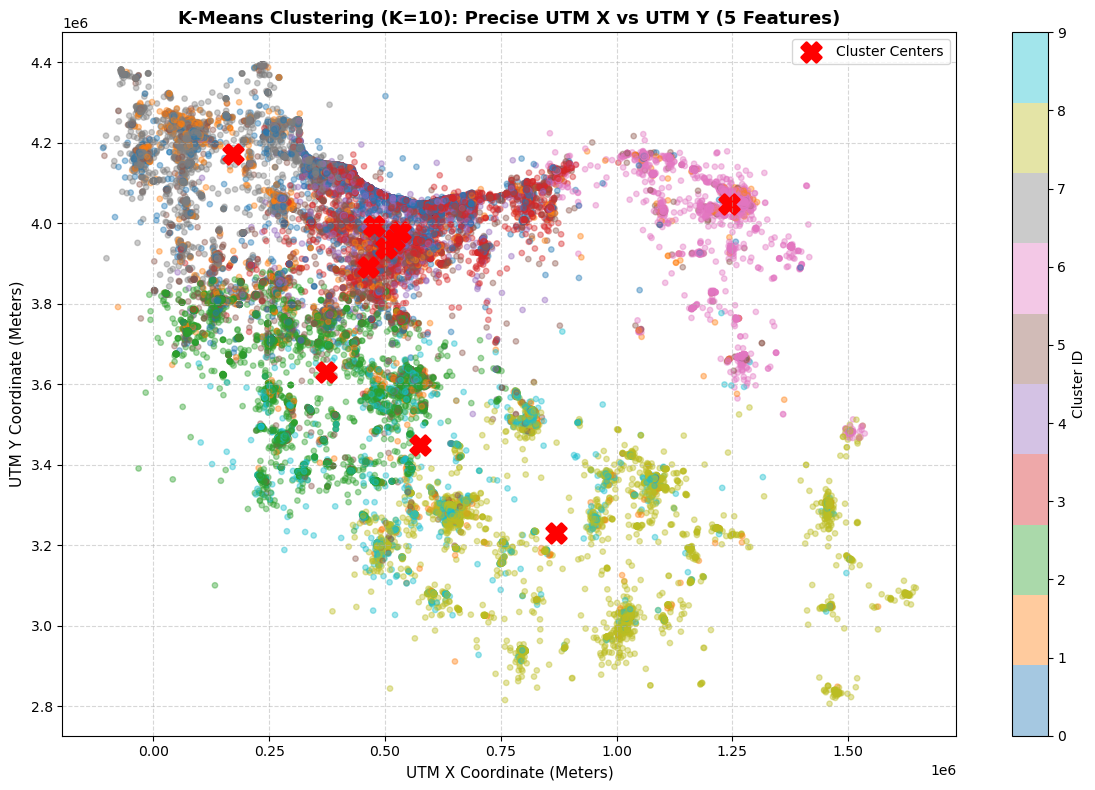

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Transformer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# خواندن و پاک‌سازی داده‌ها

file_path = "Divar.csv"
df = pd.read_csv(file_path, low_memory=False)

# آماده‌سازی متغیرها
room_mapping = {'بدون اتاق': 0, 'یک': 1, 'دو': 2, 'سه': 3, 'چهار': 4, 'پنج': 5}
df['rooms_count'] = df['rooms_count'].map(room_mapping).fillna(df['rooms_count'])
df['rooms_count'] = pd.to_numeric(df['rooms_count'], errors='coerce')
df['building_size'] = pd.to_numeric(df['building_size'], errors='coerce')
df['location_latitude'] = pd.to_numeric(df['location_latitude'], errors='coerce')
df['location_longitude'] = pd.to_numeric(df['location_longitude'], errors='coerce')
df['final_price'] = pd.to_numeric(df['price_value'], errors='coerce')

# مختصات ایران
df_clean = df[
    (df['location_latitude'] > 25) & (df['location_latitude'] < 40) &
    (df['location_longitude'] > 44) & (df['location_longitude'] < 64)
].copy()

# فیلتر قیمت و متراژ معتبر
df_clean = df_clean[
    (df_clean['final_price'] > 10000000) & 
    (df_clean['building_size'] >= 15) & 
    (df_clean['building_size'] <= 3000)
].copy()

# حذف پرت‌های قیمتی
q_low = df_clean['final_price'].quantile(0.01)
q_high = df_clean['final_price'].quantile(0.98)
df_clean = df_clean[(df_clean['final_price'] >= q_low) & (df_clean['final_price'] <= q_high)]

# تبدیل UTM
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32639", always_xy=True)
df_clean['utm_x'], df_clean['utm_y'] = transformer.transform(
    df_clean['location_longitude'].values,
    df_clean['location_latitude'].values
)

# انتخاب ۵ ویژگی و اِعمال تبدیل لوگاریتمی
features = ['utm_x', 'utm_y', 'final_price', 'building_size', 'rooms_count']
X = df_clean[features].dropna().copy()

X['final_price_log'] = np.log1p(X['final_price'])
X['building_size_log'] = np.log1p(X['building_size'])

features_model = ['utm_x', 'utm_y', 'final_price_log', 'building_size_log', 'rooms_count']
X_model = X[features_model]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_model)


# اجرای اولیه K-Means (K=10) و رسم اسکترپلات UTM

kmeans_10 = KMeans(n_clusters=10, random_state=42, n_init=10)
X['cluster_10'] = kmeans_10.fit_predict(X_scaled)

centers_scaled_10 = kmeans_10.cluster_centers_
centers_original_10 = scaler.inverse_transform(centers_scaled_10)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X['utm_x'], X['utm_y'],
    c=X['cluster_10'], cmap='tab10',
    alpha=0.4, s=15
)

plt.scatter(
    centers_original_10[:, 0], centers_original_10[:, 1],
    c='red', marker='X', s=200, linewidths=2, label='Cluster Centers'
)

plt.title('K-Means Clustering (K=10): Precise UTM X vs UTM Y (5 Features)', fontsize=13, fontweight='bold')
plt.xlabel('UTM X Coordinate (Meters)', fontsize=11)
plt.ylabel('UTM Y Coordinate (Meters)', fontsize=11)
plt.colorbar(scatter, label='Cluster ID')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

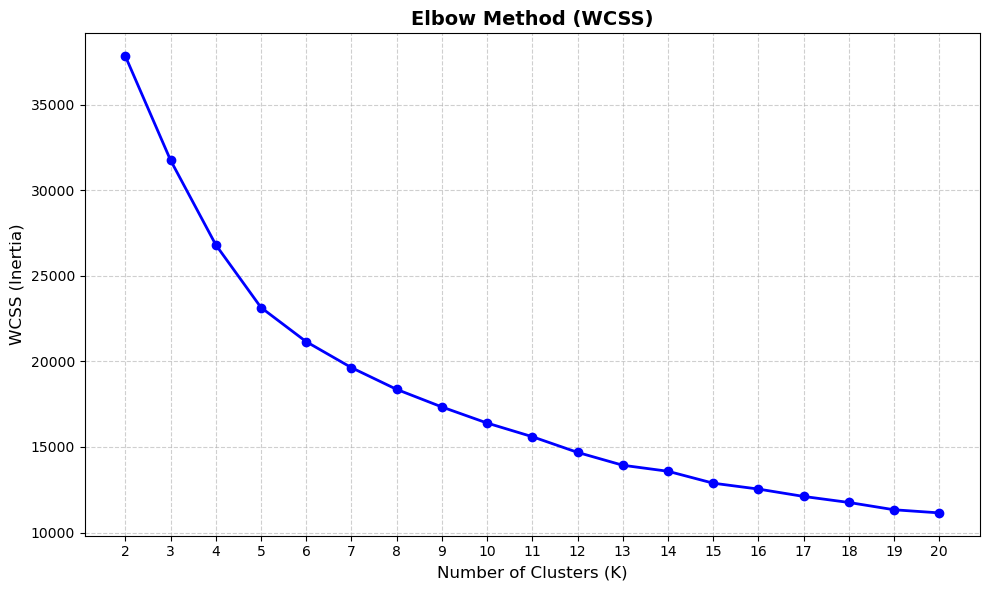

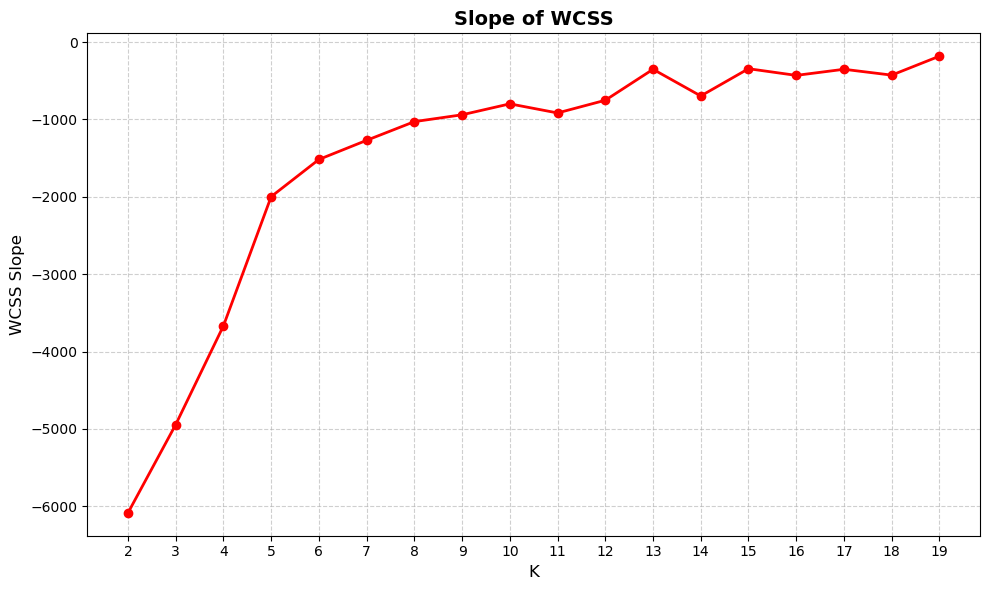

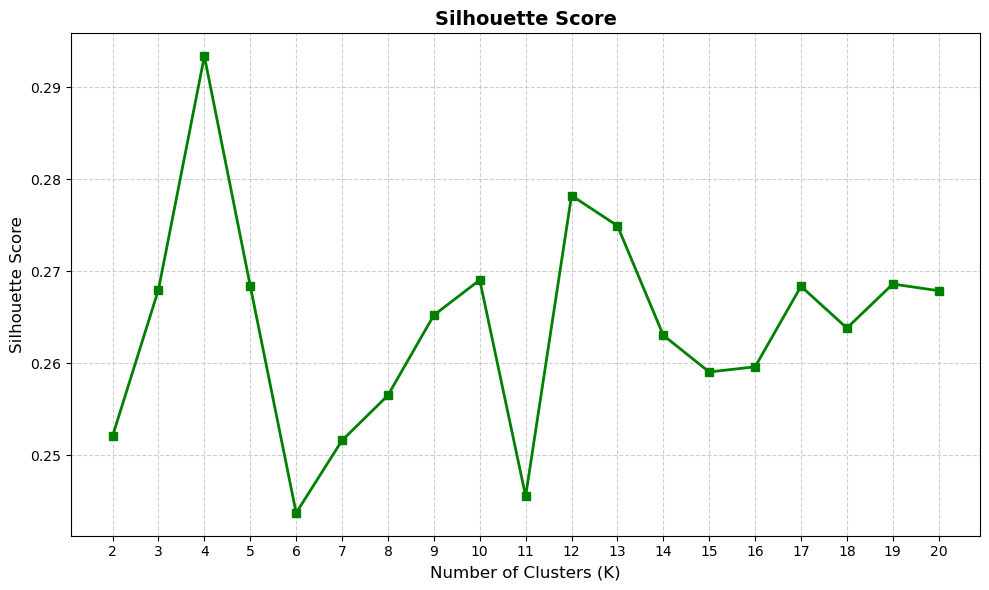

In [ ]:
from sklearn.metrics import silhouette_score


# نمونه‌گیری جهت محاسبه سریع WCSS و Silhouette

np.random.seed(42)

sample_size = min(10000, X_scaled.shape[0])
sample_indices = np.random.choice(
    X_scaled.shape[0],
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_indices]

wcss = []
silhouette_scores = []

k_range = range(2, 21)


#  محاسبه شاخص‌ها برای K بین ۲ تا ۲۰

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_sample)

    # WCSS
    wcss.append(kmeans.inertia_)

    # Silhouette Score
    silhouette_scores.append(
        silhouette_score(X_sample, cluster_labels)
    )


#  محاسبه شیب WCSS بین Kهای متوالی

wcss_slopes = []

k_values = list(k_range)

for i in range(len(wcss) - 1):

    slope = wcss[i + 1] - wcss[i]

    wcss_slopes.append(slope)

# K مربوط به هر شیب
# مثلاً شیب بین K=2 و K=3 با K=2 نمایش داده می‌شود
slope_k = k_values[:-1]



# ۴. نمودار اول: Elbow Method (WCSS)

plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    wcss,
    marker='o',
    linestyle='-',
    color='b',
    linewidth=2
)

plt.title(
    'Elbow Method (WCSS)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Number of Clusters (K)',
    fontsize=12
)

plt.ylabel(
    'WCSS (Inertia)',
    fontsize=12
)

plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()



# نمودار دوم: شیب WCSS

plt.figure(figsize=(10, 6))

plt.plot(
    slope_k,
    wcss_slopes,
    marker='o',
    linestyle='-',
    color='r',
    linewidth=2
)

plt.title(
    'Slope of WCSS',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'K',
    fontsize=12
)

plt.ylabel(
    'WCSS Slope',
    fontsize=12
)

plt.xticks(slope_k)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()



#  نمودار سوم: Silhouette Score

plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    silhouette_scores,
    marker='s',
    linestyle='-',
    color='g',
    linewidth=2
)

plt.title(
    'Silhouette Score',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Number of Clusters (K)',
    fontsize=12
)

plt.ylabel(
    'Silhouette Score',
    fontsize=12
)

plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

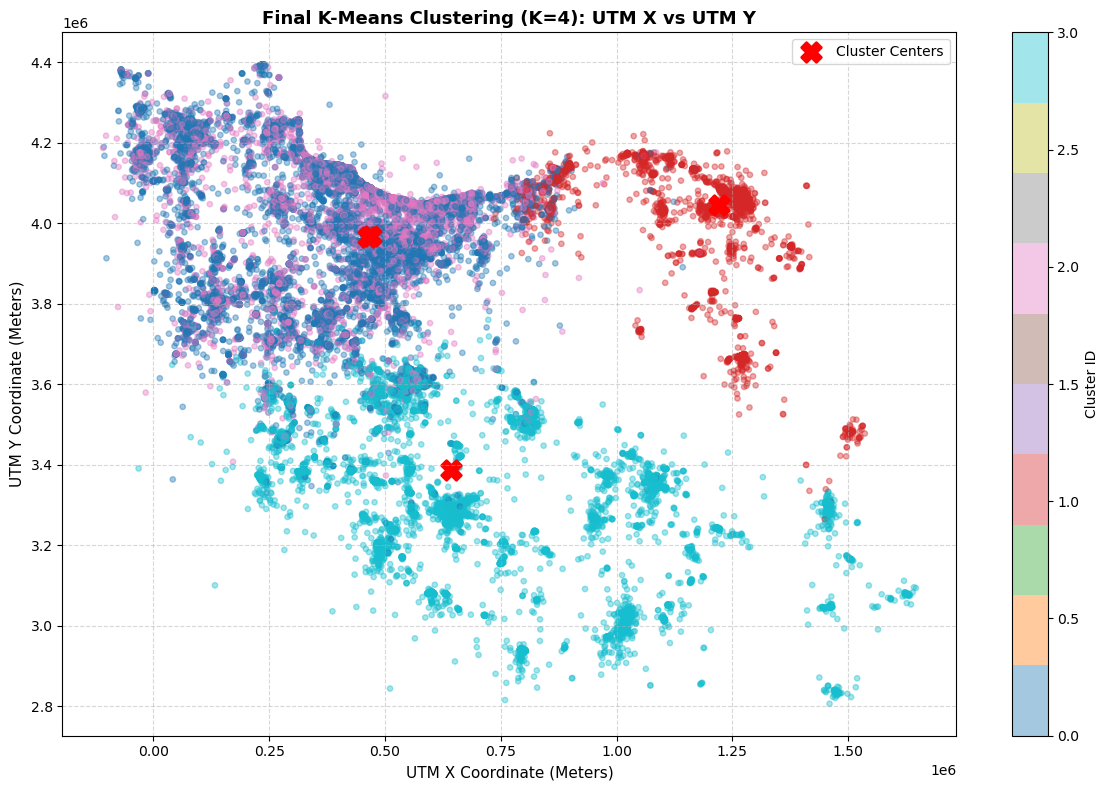

In [ ]:

#  اجرای K-Means نهایی با K=4 روی کل داده‌ها

k_optimal = 4

kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
X['cluster_final'] = kmeans_final.fit_predict(X_scaled)

# مراكز خوشه‌ها در مقیاس اصلی
centers_scaled_final = kmeans_final.cluster_centers_
centers_original_final = scaler.inverse_transform(centers_scaled_final)

#  رسم اسکترپلات UTM خوشه‌بندی نهایی (K=4)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    X['utm_x'], X['utm_y'],
    c=X['cluster_final'], cmap='tab10',
    alpha=0.4, s=15
)

# رسم مراكز خوشه‌ها
plt.scatter(
    centers_original_final[:, 0], centers_original_final[:, 1],
    c='red', marker='X', s=200, linewidths=2, label='Cluster Centers'
)

plt.title(f'Final K-Means Clustering (K={k_optimal}): UTM X vs UTM Y', fontsize=13, fontweight='bold')
plt.xlabel('UTM X Coordinate (Meters)', fontsize=11)
plt.ylabel('UTM Y Coordinate (Meters)', fontsize=11)
plt.colorbar(scatter, label='Cluster ID')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler

divar_df = pd.read_csv('./Divar.csv')

mapping = {
    'بدون اتاق': 0,
    'یک': 1,
    'دو': 2,
    'سه': 3,
    'چهار': 4,
    'پنج یا بیشتر': 5,
}
divar_df['rooms_count'] = divar_df['rooms_count'].map(mapping)
divar_df['rooms_count'].fillna(divar_df['rooms_count'])
divar_df['rooms_count'] = pd.to_numeric(divar_df['rooms_count'], errors='coerce')


divar_df['building_size'] = pd.to_numeric(divar_df['building_size'], errors='coerce')
divar_df['location_latitude'] = pd.to_numeric(divar_df['location_latitude'], errors='coerce')
divar_df['location_longitude'] = pd.to_numeric(divar_df['location_longitude'], errors='coerce')


divar_df['final_price'] = pd.to_numeric(divar_df['price_value'], errors='coerce')


df_clean = divar_df[
    (divar_df['location_latitude'] > 25) & (divar_df['location_latitude'] < 40) &
    (divar_df['location_longitude'] > 44) & (divar_df['location_longitude'] < 64)
].copy()


df_clean = df_clean[df_clean['final_price'] > 10000000].copy()

q_low = df_clean['final_price'].quantile(0.01)
q_high = df_clean['final_price'].quantile(0.98)
df_clean = df_clean[(df_clean['final_price'] >= q_low) & (df_clean['final_price'] <= q_high)]


transformer = Transformer.from_crs("EPSG:4326", "EPSG:32639", always_xy=True)

df_clean['utm_x'], df_clean['utm_y'] = transformer.transform(
    df_clean['location_longitude'].values,
    df_clean['location_latitude'].values
)

features = ['utm_x', 'utm_y', 'final_price', 'building_size', 'rooms_count']
X = df_clean[features].dropna().copy()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

/tmp/ipykernel_67173/3522368810.py:8: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  divar_df = pd.read_csv('./Divar.csv')


## elbow method

In [ ]:
WCSS = []

for k in range(1, 21):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    WCSS.append(kmeans.inertia_)

In [ ]:
from kneed import KneeLocator

knee_loc = KneeLocator(range(1,21), WCSS, curve="convex", direction="decreasing")
best_k = knee_loc.elbow
print("best k:", best_k)

best k: 6


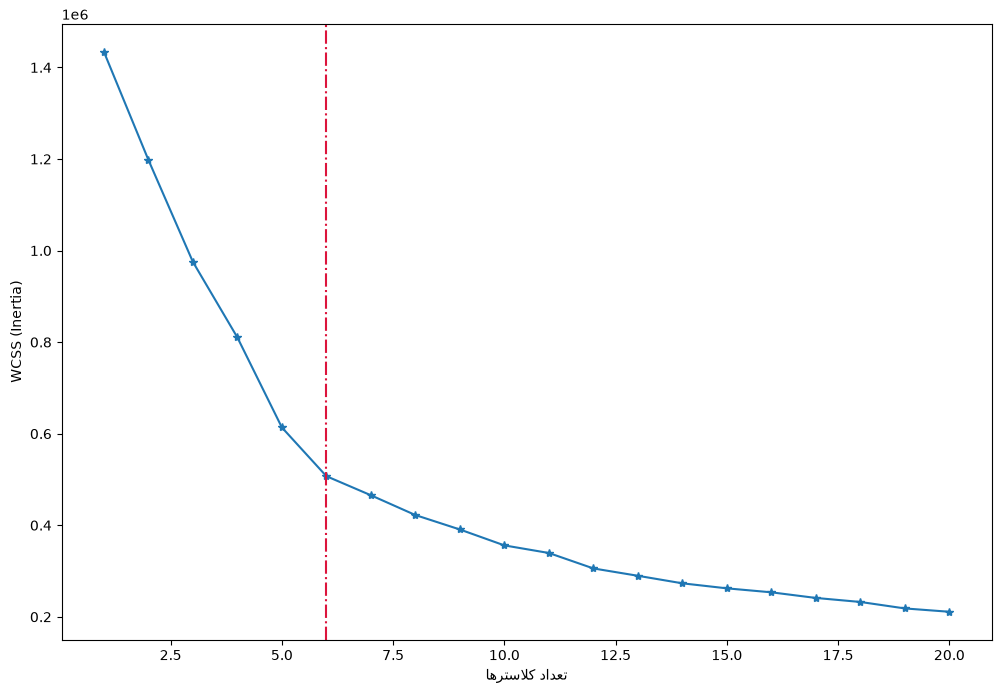

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(range(1,21), WCSS, marker='*')
plt.axvline(x=best_k, color='crimson', linestyle='-.')
plt.xlabel("تعداد کلاسترها")
plt.ylabel("WCSS (Inertia)")
plt.show()

In [ ]:
#3
import sys
print(sys.executable)
!{sys.executable} -m pip install pyproj

c:\Users\lenovo\AppData\Local\Programs\Python\Python312\python.exe



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
data = pd.read_csv('Divar.csv')
data[['transformable_price','price_value','transformable_credit','transformed_credit','credit_value','transformable_rent','transformed_rent','rent_value']].head(20)

,transformable_price,price_value,transformable_credit,transformed_credit,credit_value,transformable_rent,transformed_rent,rent_value
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,8.500000e+09,NaN,NaN,NaN,NaN,NaN,NaN
2,False,NaN,7.500000e+08,NaN,7.500000e+08,26000000.0,NaN,26000000.0
3,False,NaN,9.500000e+08,NaN,9.500000e+08,95000000.0,NaN,95000000.0
4,NaN,5.750000e+09,NaN,NaN,NaN,NaN,NaN,NaN
5,True,NaN,2.500000e+08,400000000.0,2.500000e+08,6000000.0,1.0,6000000.0
6,False,NaN,1.500000e+08,NaN,1.500000e+08,16000000.0,NaN,16000000.0
7,NaN,8.700000e+09,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,6.500000e+08,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,3.000000e+09,NaN,NaN,NaN,NaN,NaN,NaN


0             NaN
1    8.500000e+09
2             NaN
3             NaN
4    5.750000e+09
Name: transform, dtype: float64
eps=0.5, min_samples=100 -> 3 کلاستر، نویز=316


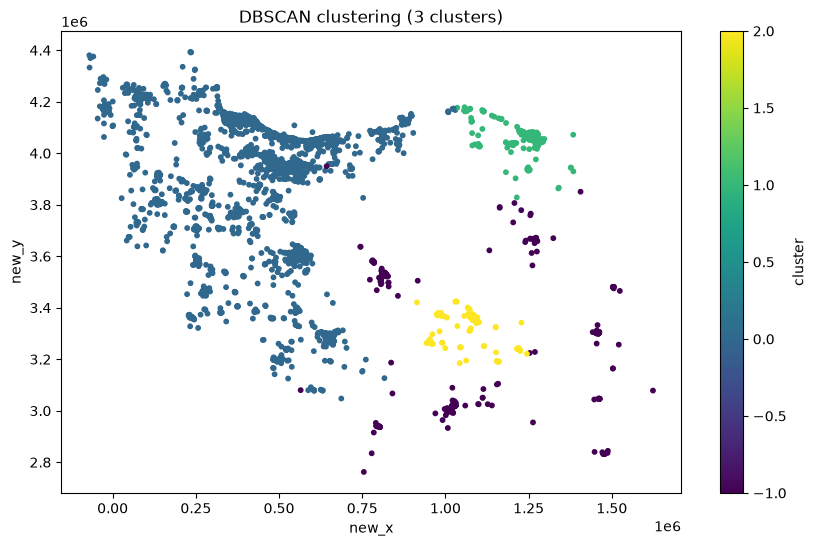

cluster
-1    5.678647e+11
 0    6.096332e+09
 1    4.762730e+09
 2    3.139026e+09
Name: transform, dtype: float64


In [ ]:
tp = data['transformable_price'].fillna(False).astype(bool)

s = data[['transformed_credit', 'transformed_rent']].sum(axis=1, min_count=1)

data['transform'] = np.where(
    data['price_value'].notna(), data['price_value'],
    np.where(tp, s, np.nan)
)
print(data['transform'].head())
transformed = Transformer.from_crs("EPSG:4326", "EPSG:32639", always_xy=True)
cluster_data = data[['location_latitude', 'location_longitude', 'transform']].copy()
x,y = transformed.transform(cluster_data['location_longitude'].values, cluster_data['location_latitude'].values)
cluster_data['new_x'] = x 
cluster_data['new_y'] = y
# cluster_data['transform'].plot(kind='hist',figsize=(10,5))

scaler = StandardScaler()
cluster_data = cluster_data[['new_x', 'new_y', 'transform']].dropna()
cluster_data = cluster_data.sample(n=10000, random_state=0)
cluster_data_s = scaler.fit_transform(cluster_data[['new_x', 'new_y', 'transform']])
from sklearn.cluster import DBSCAN
dbs = DBSCAN(eps=0.3, min_samples=20)

result = dbs.fit_predict(cluster_data_s)

cluster_data_s = scaler.fit_transform(cluster_data[['new_x', 'new_y', 'transform']])
for eps in [0.1, 0.15, 0.2, 0.3, 0.4, 0.5]:
    for ms in [10, 20, 50, 100]:
        lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(cluster_data_s)
        k = len(set(lab)) - (1 if -1 in lab else 0)
        if k==3:
          print(f'eps={eps}, min_samples={ms} -> {k} کلاستر، نویز={(lab==-1).sum()}')
dbs = DBSCAN(eps=0.5, min_samples=100)
labels = dbs.fit_predict(cluster_data_s)

plt.figure(figsize=(10, 6))
plt.scatter(cluster_data.iloc[:, 0], cluster_data.iloc[:, 1],
            c=labels, cmap='viridis', s=10)
plt.xlabel(cluster_data.columns[0])
plt.ylabel(cluster_data.columns[1])
plt.title('DBSCAN clustering (3 clusters)')
plt.colorbar(label='cluster')
plt.show()
cluster_data['cluster'] = labels
print(cluster_data.groupby('cluster')['transform'].mean())


In [ ]:
data[['transformable_credit','transformed_credit']].sample(10,random_state=44)
data[['transformed_rent','transformable_rent']].sample(10,random_state=44)
data['transformable_credit'].describe()
data['rent_credit_transform'].describe()
data['price_value'].isnull().sum()
data['transformable_price'].describe()
print(data['price_value'].median())
print(data['transformable_credit'].median())
print(data['transformed_credit'].median())
print(data['transformed_rent'].median())
print(data['transformable_rent'].median())

2840000000.0
250000000.0
400000000.0
6000000.0
5000000.0


0             NaN
1    8.500000e+09
2    1.616667e+10
3    4.116667e+10
4    5.750000e+09
Name: transform, dtype: float64
0
eps=0.1, min_samples=150 تعدادکلاستر 3 کلاستر نویز=11667
eps=0.5, min_samples=150 تعدادکلاستر 3 کلاستر نویز=1284
eps=0.5, min_samples=230 تعدادکلاستر 3 کلاستر نویز=1809
eps=0.5, min_samples=250 تعدادکلاستر 3 کلاستر نویز=1889


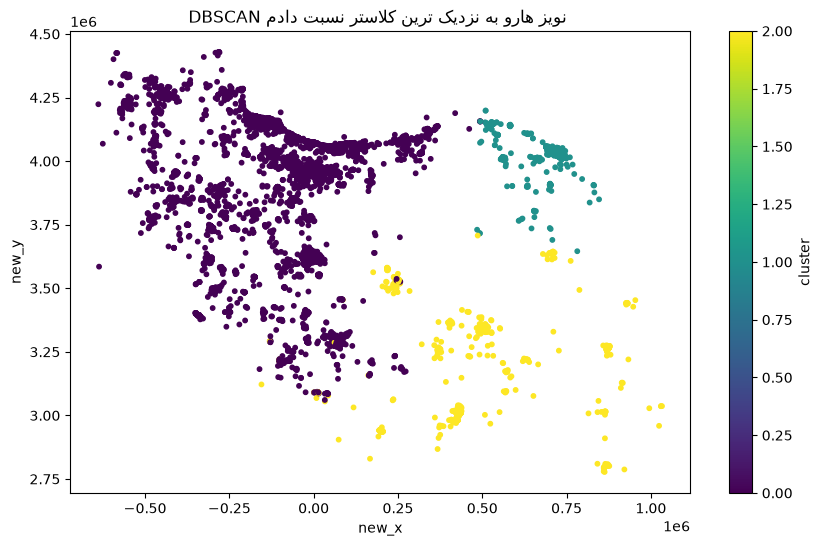

cluster
0    5.784592e+09
1    4.689497e+09
2    5.639235e+09
Name: transform, dtype: float64


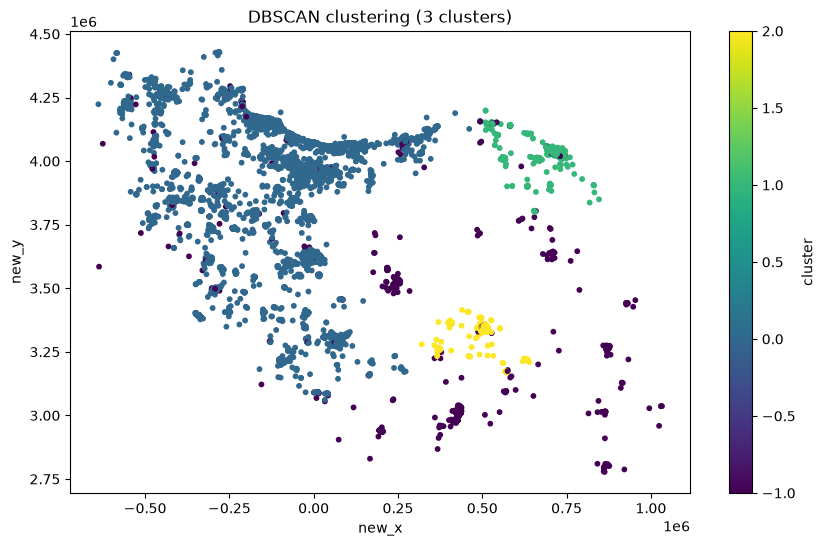

cluster
-1    1.220757e+10
 0    5.417596e+09
 1    3.641232e+09
 2    2.836270e+09
Name: transform, dtype: float64


In [ ]:
tp = data['transformable_price'].fillna(False).astype(bool)

def calc_price(row):
    price, rent, credit = row.get("price_value"), row.get("rent_value"), row.get("credit_value")
    if pd.notna(price) :
        return price
    has_rent = pd.notna(rent) 
    has_credit = pd.notna(credit) 
    if has_rent and has_credit:
        return ((rent / 3) * 100 + credit) * 10
    if has_rent:
        return (rent / 3) * 100 * 10
    if has_credit:
        return credit * 100
    return np.nan
# //////////////////////////////////////////////////////////////////////////////
data['transform'] = data.apply(calc_price, axis=1)
print(data['transform'].head())
transformed = Transformer.from_crs("EPSG:4326",'EPSG:32640', always_xy=True)
cluster_data = data[['location_latitude', 'location_longitude', 'transform']].copy()
x,y = transformed.transform(cluster_data['location_longitude'].values, cluster_data['location_latitude'].values)
cluster_data['new_x'] = x 
cluster_data['new_y'] = y
cluster_data = cluster_data[
    cluster_data['new_x'].between(-700_000, 1_120_000) &cluster_data['new_y'].between(2_750_000, 4_500_000)]
mi,ma = cluster_data['transform'].quantile([0.03, 0.97])
cluster_data = cluster_data[cluster_data['transform'].between(mi, ma)]
# cluster_data['transform'].plot(kind='hist',figsize=(10,5))
print(cluster_data['transform'].isnull().sum())
cluster_data = cluster_data.dropna()
scaler = StandardScaler()
cluster_data = cluster_data[['new_x', 'new_y', 'transform']].dropna()
cluster_data = cluster_data.sample(n=20000, random_state=0)
cluster_data_s = scaler.fit_transform(cluster_data[['new_x', 'new_y', 'transform']])
from sklearn.cluster import DBSCAN
cluster_data_s = scaler.fit_transform(cluster_data[['new_x', 'new_y', 'transform']])
for eps in [0.1, 0.15, 0.2, 0.3, 0.4, 0.5]:
    for ms in [10, 20, 50, 100,150,200,205,230,250]:
        lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(cluster_data_s)
        k = len(set(lab)) - (1 if -1 in lab else 0)
        if k==3:
           print(f'eps={eps}, min_samples={ms} تعدادکلاستر {k} کلاستر نویز={(lab==-1).sum()}')
dbs = DBSCAN(eps=0.5, min_samples=150)
labels = dbs.fit_predict(cluster_data_s)
#  مرکز هر کلاستر بدون نویز
unique_labels = [l for l in set(labels) if l != -1]
center= np.array([cluster_data_s[labels == l].mean(axis=0) for l in unique_labels])
#   نویزها به نزدیک‌ترین مرکز
noise_ = labels == -1
if noise_.any():
    noise_points = cluster_data_s[labels == -1]
    dists = np.linalg.norm(noise_points[:, None, :] - center[None, :, :], axis=2)
    nearest = np.argmin(dists, axis=1)
    labels[noise_] = np.array(unique_labels)[nearest]

cluster_data['cluster'] = labels
plt.figure(figsize=(10, 6))
plt.scatter(cluster_data['new_x'], cluster_data['new_y'],
            c=labels, cmap='viridis', s=10)
plt.xlabel('new_x'); plt.ylabel('new_y')
plt.title('DBSCAN نویز هارو به نزدیک ترین کلاستر نسبت دادم ')
plt.colorbar(label='cluster')
plt.show()
# /////////////////////////////////////////////////////////////////////////////////
print(cluster_data.groupby('cluster')['transform'].mean())
# ////////////////////////////////////////////////////////////////////
labels = dbs.fit_predict(cluster_data_s)
plt.figure(figsize=(10, 6))
plt.scatter(cluster_data.iloc[:,0], cluster_data.iloc[:,1],c=labels, cmap='viridis', s=10)
plt.xlabel(cluster_data.columns[0])
plt.ylabel(cluster_data.columns[1])
plt.title('DBSCAN clustering (3 clusters)')
plt.colorbar(label='cluster')
plt.show()
cluster_data['cluster'] = labels
print(cluster_data.groupby('cluster')['transform'].mean())
